<a href="https://colab.research.google.com/github/armeros/DC_Stats_Sampling/blob/main/Sampling_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, scipy, seaborn as sns
pd.options.display.float_format = lambda x: f'{x:.2f}'.rstrip('0').rstrip('.')

In order to fully understand this you need to understand [Introduction to Statistics in Python](https://app.datacamp.com/learn/courses/introduction-to-statistics-in-python).  That means how to implement simple descriptive statistics knowledge and some random variables in Python.

# **Population vs Sample**

* **Population** = WHOLE dataset, say **`df`**
* **Sample** = **`df.sample(n=100)`**

>> Actually, your **`df`** is a sample from the whole population.  But to demonstrate sampling in Python we consider **`df`** a population.

## **Reasons for sampling**

Sampling is an important technique in your statistical arsenal. It isn't always appropriate though—you need to know when to use it and when to work with the whole dataset.

<u>Examples to use sampling</u>:
* You've been handed one terabyte of data about error logs for your company's device.
* You wish to learn about the travel habits of all Pakistani adult citizens.
* You are working to predict customer turnover on a big data project for your marketing firm.

<u>When not use sampling</u>:
* You've finished collecting data on *a small study* of the wing measurements for 10 butterflies. Ten butterflies is a small dataset, so sampling isn't useful here.

## ***Population statistics and sample statistics***

In this topic,

- **`df.mean()`** is population mean
- **`df.sample(n=100)`**.mean() is sample mean

#### ***Exercise: Simple sampling with pandas***

You'll be exploring song data from Spotify. Each row of this population dataset represents a song, and there are over 40,000 rows. Columns include the song name, the artists who performed it, the release year, and attributes of the song like its duration, tempo, and danceability. You'll start by looking at the durations.

Your first task is to sample the Spotify dataset and compare the mean duration of the population with the sample.

`spotify_population` is available and `pandas` is loaded as `pd`.

#### **Instructions**

* Sample 1,000 rows from `spotify_population`, assigning to `spotify_sample`.

* Calculate the mean duration in minutes from `spotify_population` using **`pandas`**.

* Calculate the mean duration in minutes from `spotify_sample` using **`pandas`**.

In [ ]:
import pandas as pd

spotify_population = pd.read_feather('spotify_2000_2020.feather')

# Sample 1000 rows from spotify_population
spotify_sample = spotify_population.sample(n=1000)

display(spotify_sample.head())

# Calculate the mean duration in mins from spotify_population
mean_dur_pop = spotify_population['duration_minutes'].mean()
# Calculate the mean duration in mins from spotify_sample
mean_dur_samp = spotify_sample['duration_minutes'].mean()

# Print the means
print(mean_dur_pop)  # Population mean
print(mean_dur_samp) # Sample mean


Notice that the mean song duration in the sample is similar, but not identical to the mean song duration in the whole population.

#### ***Exercise: Simple sampling and calculating with NumPy***

You can also use **`numpy`** to calculate parameters or statistics from a list or **`pandas`** Series.

You'll be turning it up to eleven and looking at the loudness property of each song.

`spotify_population` is available and **`numpy`** is loaded as `np`.

#### **Instructions**

* Create a pandas Series, `loudness_pop`, by subsetting the `loudness` column from `spotify_population`.

* Sample `loudness_pop` to get `100` random values, assigning to `loudness_samp`.

* Calculate the mean of `loudness_pop` using **`numpy`**.
* Calculate the mean of `loudness_samp` using **`numpy`**.

In [ ]:
import numpy as np

loudness_pop = spotify_population['loudness']
loudness_samp = loudness_pop.sample(n=100)

mean_loudness_pop = np.mean(loudness_pop)
mean_loudness_samp = np.mean(loudness_samp)

print(mean_loudness_pop)
print(mean_loudness_samp)

Again, notice that the calculated value (the mean) is ***close but not identical*** in each case.

# **Convenience Sampling**

Collecting data by the easiest method *often leads to biased data*.

- Example: Collecting data about voting only from the rich people
- Example: Collecting ages from those coming to the theme park

## **Coffee ratings**

In [ ]:
coffee_ratings = pd.read_feather('/content/coffee_ratings_full.feather')
coffee_ratings['total_cup_points'].mean()

The easiest demonstration for "too convenient" sampling is only sampling from this first 10 rows

In [ ]:
coffee_ratings['total_cup_points'].head(10).mean()

These two are too far apart.

## **Visualizing selection bias**

In [ ]:
import matplotlib.pyplot as plt

# bins only from 59 to 91
coffee_ratings['total_cup_points'].hist(bins=np.arange(59, 93, 2), edgecolor='black')
plt.title("Whole poulation")
plt.show()

In [ ]:
coffee_ratings['total_cup_points'].head(10).hist(bins=np.arange(59, 93, 2))
plt.title("Sample of the first 10 observations")
plt.show()

In [ ]:
coffee_ratings['total_cup_points'].sample(10).hist(bins=np.arange(59, 93, 2))
plt.title("10 random samples")
plt.show()

#### ***Exercise: Are findings from the sample generalizable?***

You just saw how convenience sampling—collecting data using the easiest method—can result in samples that aren't representative of the population. Equivalently, this means findings from the sample are not generalizable to the population. Visualizing the distributions of the population and the sample can help determine whether or not the sample is representative of the population.

The Spotify dataset contains an `acousticness` column, which is a confidence measure from zero to one of whether the track was made with instruments that aren't plugged in. You'll compare the `acousticness` distribution of the total population of songs with a sample of those songs.

`spotify_population` and `spotify_mysterious_sample` are available; **`pandas`** as `pd`, **`matplotlib.pyplot`** as `plt`, and **`numpy`** as `np` are loaded.

#### **Instructions**

* Plot a histogram of the `acousticness` from `spotify_population` with bins of width `0.01` from `0` to `1` using pandas **`.hist()`**.

In [ ]:
spotify_population['acousticness'].hist(bins=np.arange(0, 1.01, 0.01))
plt.show()

* Use `spotify_mysterious_sample`


In [ ]:
# Update the histogram to use spotify_mysterious_sample
spotify_mysterious_sample['acousticness'].hist(bins=np.arange(0, 1.01, 0.01))
plt.show()

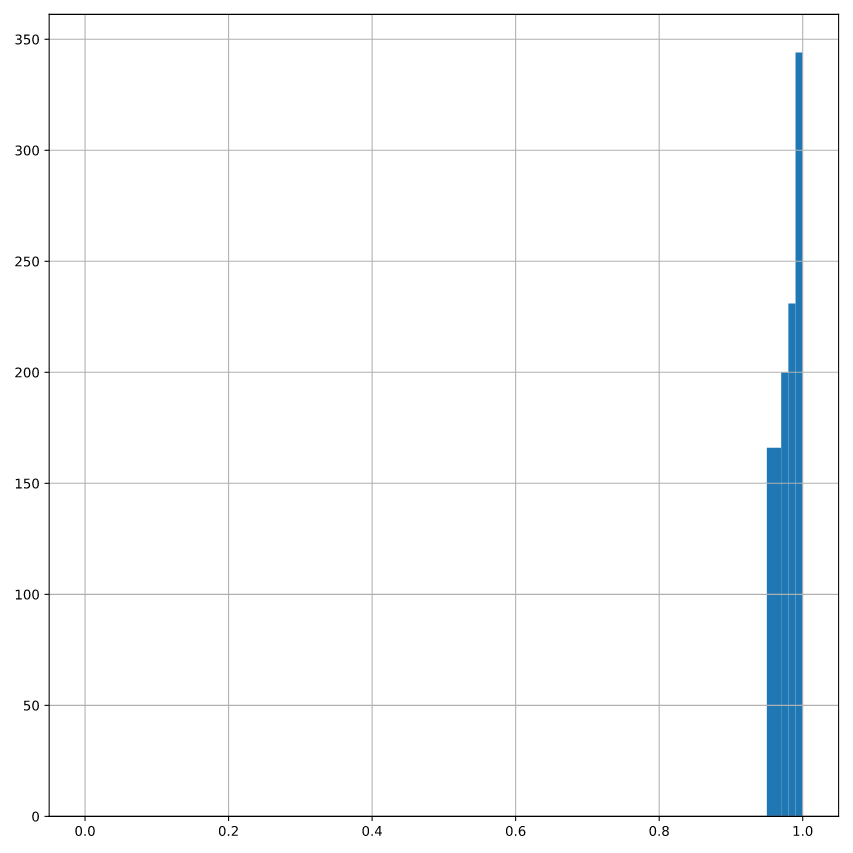

The acousticness samples are consistently higher than those in the general population.  The acousticness values in the sample are all greater than 0.95, whereas they range from 0 to 1 in the whole population.

#### **Exercise: Are these findings generalizable?**

Let's look at another sample to see if it is representative of the population. This time, you'll look at the `duration_minutes` column of the Spotify dataset, which contains the length of the song in minutes.

`spotify_population` and `spotify_mysterious_sample2` are available; `pandas`, `matplotlib.pyplot`, and `numpy` are loaded using their standard aliases.

#### **Instructions**

* Plot a histogram of `duration_minutes` from `spotify_population` with `bins` of width 0.5 from 0 to 15 using pandas `.hist()`.

In [ ]:
spotify_population['duration_minutes'].hist(bins=np.arange(0, 15.5, 0.5))
plt.show()

* Use the `spotify_mysterious_sample2` dataset.

In [ ]:
spotify_mysterious_sample2['duration_minutes'].hist(bins=np.arange(0, 15.5, 0.5))
plt.show()

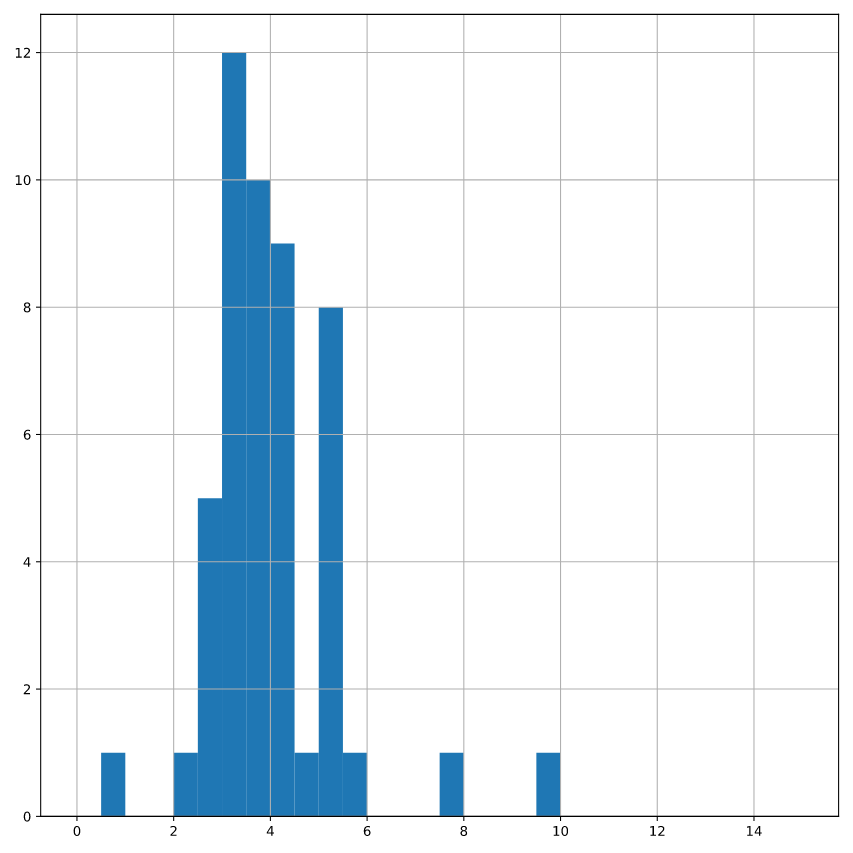

The sample selected is likely a random sample of all songs in the population. The results are generalizable.

# **Pseudo-random number generation**

- Not truly random but able to replicate the results

### **Random number generating functions**

- Generate random variables
```text
*----------------*------------------*
|Function        | Distribution     |
*----------------*------------------*
.beta             Beta
.hypergeometric   Hypergeometric
.binomial         Binomial
.lognormal        Lognormal
.chisquare        Chi-squared
.negative_binomial Negative binomial
.exponential      Exponential
.normal            Normal
.f                 F
.poisson           Poisson
.gamma             Gamma
.standard_t        t
.geometric         Geometric
.uniform           Uniform
```

- We usually use Normal, Uniform, t, Poisson, Chi-squared, and F

In [ ]:
fig, ax = plt.subplots()

# No need to know what a and b are for this
ax.hist(np.random.beta(a=2, b=2, size=5000), bins=np.arange(0, 1, 0.05), edgecolor='black')
plt.show()

## **Random numbers seeds**

- `loc=` is μ.
- `scale=` is σ

In [ ]:
np.random.seed(20000229)
print(np.random.normal(loc=2, scale=1.5, size=2))
print(np.random.normal(loc=2, scale=1.5, size=2))

Seed makes code reproducible.

In [ ]:
np.random.seed(20000229)
print(np.random.normal(loc=2, scale=1.5, size=2))
print(np.random.normal(loc=2, scale=1.5, size=2))

#### ***Exercise: Generating random numbers***

You've used `.sample()` to generate pseudo-random numbers from a set of values in a DataFrame. A related task is to generate random numbers that follow a statistical distribution, like the uniform distribution or the normal distribution.

Each random number generation function has distribution-specific arguments and an argument for specifying the number of random numbers to generate.

#### ***Instructions***

* Generate 5,000 numbers from a uniform distribution, setting the parameters `low` to `-3` and `high` to `3`.

* Generate 5,000 numbers from a normal distribution, setting the parameters `loc` to `5` and `scale` to `2`.

* Plot a histogram of uniforms with `bins` of width of `0.25` from `-3` to `3` using pandas `.hist()`.

* Plot a histogram of normals with `bins` of width of `0.5` from `-2` to `13` using pandas `.hist()`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Generate random numbers from a Uniform(-3, 3)
uniforms = np.random.uniform(low=-3, high=3, size=5000)

# Plot a histogram of uniform values, binwidth 0.25
ax[0].hist(uniforms, bins=np.arange(-3, 3.1, 0.25), edgecolor='white')


# Generate random numbers from a Normal(5, 2)
normals = np.random.normal(loc=5, scale=2, size=5000)

# Plot a histogram of normal values, binwidth 0.5
ax[1].hist(normals, bins=np.arange(-2, 13.1, 0.5), edgecolor='white')
plt.show()

Notice how the histograms almost take the flat and bell curve shapes of the uniform and normal distributions, but there is a bit of random noise.

#### ***Exercise: Understanding random seeds***

While random numbers are important for many analyses, they create a problem: the results you get can vary slightly. This can cause awkward conversations with your boss when your script for calculating the sales forecast gives different answers each time.

Setting the seed for numpy's random number generator helps avoid such problems by making the random number generation reproducible.

Which statement about x and y is true?

```
import numpy as np
np.random.seed(123)
x = np.random.normal(size=5)
y = np.random.normal(size=5)
```
The values of x are different from those of y.

```
np.random.seed(123)
x = np.random.normal(size=5)
np.random.seed(123)
y = np.random.normal(size=5)
```

x and y have identical values

```
np.random.seed(123)
x = np.random.normal(size=5)
np.random.seed(456)
y = np.random.normal(size=5)
```

x and y differs



# **Simple random sampling and systematic random sampling**

## **Simple random sampling**

In [ ]:
import pandas as pd
coffee_ratings = pd.read_feather('coffee_ratings_full.feather')
coffee_ratings.sample(n=5, random_state=19000113)[['total_cup_points', 'variety', 'country_of_origin', 'aroma', 'flavor', 'aftertaste', 'body', 'balance']]

## **Systematic sampling - defining an interval**

In [ ]:
sample_size = 5
interval = len(coffee_ratings) // sample_size
interval

Select one sample from every 267 samples.

In [ ]:
coffee_ratings.iloc[::interval][['total_cup_points', 'variety', 'country_of_origin', 'aroma', 'flavor', 'aftertaste', 'body', 'balance']]

## **Problem with systematic sampling**

In [ ]:
coffee_ratings.reset_index().plot(x='index', y='aftertaste', kind='scatter')
plt.show()

Early rows tend to have higher `aftertaste` than later rows.  This bias the sample.  The unbiased sample must not show any pattern.

## **Making systematic sampling not biased**

In [ ]:
# Randomize the whole dataset
shuffled = coffee_ratings.sample(frac=1) # frac=1 means whole data
shuffled = shuffled.reset_index(drop=True).reset_index()
shuffled.plot(x="index", y="aftertaste", kind="scatter")
plt.show()

Once we shuffle the rows, systematic sampling is <u>***essentially the same***</u> as simple random sampling.

#### ***Exercise: Simple random sampling***

The simplest method of sampling a population is the one you've seen already. It is known as simple random sampling (sometimes abbreviated to "SRS"), and involves picking rows at random, one at a time, where each row has the same chance of being picked as any other.

In this chapter, you'll apply sampling methods to a synthetic (fictional) employee attrition dataset from IBM, where "attrition" in this context means leaving the company.

* Sample 70 rows from `attrition_pop` using simple random sampling, setting the random seed to `18900217`.
* Print the sample dataset, `attrition_samp`. What do you notice about the indices?

In [ ]:
import pandas as pd

attrition_pop = pd.read_feather('attrition.feather')

# Sample 70 rows using simple random sampling and set the seed
attrition_samp = attrition_pop.sample(n=70, random_state=18900217)

# Print the sample
attrition_samp

Notice how ***the indexes in the sample aren't always in increasing order***. They are just random.

#### ***Exercise: Systematic sampling***

One sampling method that avoids randomness is called systematic sampling. Here, you pick rows from the population at regular intervals.

For example, if the population dataset had one thousand rows, and you wanted a sample size of five, you could pick rows 0, 200, 400, 600, and 800.

* Set the sample size to `70`.
* Calculate the population size from `attrition_pop`.
* Calculate the interval between the rows to be sampled.
* Systematically sample `attrition_pop` to get the rows of the population at each interval, starting at `0`; assign the rows to `attrition_sys_samp`.

In [ ]:
import pandas as pd

attrition_pop = pd.read_feather('attrition.feather')

# Set the sample size to 70
sample_size = 70

# Calculate the population size from attrition_pop
pop_size = attrition_pop.shape[0]

# Calculate the interval
interval = pop_size//sample_size

# Systematically sample 70 rows
attrition_sys_samp = attrition_pop.iloc[::interval]

# Print the sample
attrition_sys_samp

 Systematic sampling avoids randomness by picking rows at regular intervals.

 #### ***Exercise: Is systematic sampling OK?***

Systematic sampling has a problem: if the data has been sorted, or there is some sort of pattern or meaning behind the row order, then the resulting sample may not be representative of the whole population. The problem can be solved by shuffling the rows, but then systematic sampling is equivalent to simple random sampling.

* Add an index column to `attrition_pop`, assigning the result to `attrition_pop_id`.
* Create a scatter plot of `YearsAtCompany` versus index for `attrition_pop_id`.

In [ ]:
import pandas as pd

attrition_pop = pd.read_feather('attrition.feather')

# Add an index column to attrition_pop
attrition_pop_id = attrition_pop.reset_index()

# Plot YearsAtCompany vs. index for attrition_pop_id
attrition_pop_id.plot(x='index', y='YearsAtCompany', kind='scatter')
plt.show()

* Randomly shuffle the rows of `attrition_pop`.
* Reset the row indexes, and add an index column to `attrition_pop`.
* Repeat the scatter plot of `YearsAtCompany` versus `index`, this time using `attrition_shuffled`.

In [ ]:
# Shuffle the rows of attrition_pop
attrition_shuffled = attrition_pop.sample(frac=1)

# Reset the row indexes and create an index column
attrition_shuffled = attrition_shuffled.reset_index(drop=True).reset_index()

# Plot YearsAtCompany vs. index for attrition_shuffled
attrition_shuffled.plot(x='index', y='YearsAtCompany', kind='scatter')
plt.show()

 Systematic sampling has problems when the data are sorted or contain a pattern. Shuffling the rows makes it equivalent to simple random sampling.

# **Stratification Sampling**

Stratified sampling is useful if you care about subgroups. Otherwise, simple random sampling is more appropriate.

In [ ]:
import pandas as pd

coffee_ratings = pd.read_feather('coffee_ratings_full.feather')

top_counts = coffee_ratings['country_of_origin'].value_counts(normalize=True)
top_counts.head(6)

## ***10 % Simple Random Sample***

In [ ]:
top_counted_countries = ["Mexico", "Colombia", "Guatemala", "Brazil", "Taiwan", "United States (Hawaii)"]
top_counted_subset = coffee_ratings['country_of_origin'].isin(top_counted_countries)

# Population
print('************Population************')
coffee_ratings_top = coffee_ratings[top_counted_subset]
display(coffee_ratings_top['country_of_origin'].value_counts(normalize=True))


# 10% Sample
print('*************Sample************')
coffee_ratings_samp = coffee_ratings_top.sample(frac=0.1, random_state=2021)
coffee_ratings_samp['country_of_origin'].value_counts(normalize=True)

Population proportion and sample proportion differ a little

## ***Proportional stratified sampling***

- **`.groupby()`** must be used to get similar (or as close as) proportion of sample to population
- **`.sample()`** after **`.groupby()`** takes a simple random sample within each country

In [ ]:
coffee_ratings_strat = coffee_ratings_top.groupby("country_of_origin").sample(frac=0.1, random_state=2021)

coffee_ratings_strat['country_of_origin'].value_counts(normalize=True)

## ***Equal counts stratified sampling***

- Specify the number of samples in each group by using `n=` instead of `frac=`

In [ ]:
                                                                        # Use n here
coffee_ratings_eq = coffee_ratings_top.groupby("country_of_origin").sample(n=15, random_state=2021)
coffee_ratings_eq['country_of_origin'].value_counts(normalize=True)

## ***Weighted random sampling***

In [ ]:
import numpy as np

coffee_ratings_weight = coffee_ratings_top
condition =   coffee_ratings_weight['country_of_origin'] == "Taiwan"

# Give twice the weight to row where country is Taiwan
# coffee_ratings_weight['weight'] = np.where(condition, 2, 1)# <=== This one gets warning

coffee_ratings_weight.loc[condition, 'weight'] = 2
coffee_ratings_weight.loc[~condition, 'weight'] = 1
display(coffee_ratings_weight['weight'].sample(5, random_state=12))
print("\n")

coffee_ratings_weight = coffee_ratings_weight.sample(frac=0.1, weights="weight", random_state=12)
coffee_ratings_weight['country_of_origin'].value_counts(normalize=True)

You can see that the proportion of Taiwaneese coffee increases as close to twice as before

>>  Stratified sampling is useful ***if you care about subgroups***. Otherwise, simple random sampling is more appropriate.

#### ***Exercise: Proportional stratified sampling***

If you are interested in subgroups within the population, then you may need to carefully control the counts of each subgroup within the population. Proportional stratified sampling results in subgroup sizes within the sample that are representative of the subgroup sizes within the population. It is equivalent to performing a simple random sample on each subgroup.

* Get the proportion of employees by Education level from `attrition_pop`.

In [ ]:
import pandas as pd

attrition_pop = pd.read_feather('attrition.feather')

# Proportion of employees by Education level
education_counts_pop = attrition_pop['Education'].value_counts(normalize=True)

# Print education_counts_pop
education_counts_pop

* Use proportional stratified sampling on `attrition_pop` to sample 40% of each Education group, setting the seed to `2022`.

In [ ]:
# Proportional stratified sampling for 40% of each Education group
attrition_strat = attrition_pop.groupby('Education', observed=True).sample(frac=0.4, random_state=2022)

attrition_strat.head()

Get the proportion of employees by Education level from `attrition_strat`.

In [ ]:
# Calculate the Education level proportions from attrition_strat
education_counts_strat = attrition_strat['Education'].value_counts(normalize=True)

# Print education_counts_strat
education_counts_strat

By grouping then sampling, the size of each group in the sample is representative of the size of the sample in the population.

#### ***Exercise: Equal counts stratified sampling***

If one subgroup is larger than another subgroup in the population, but you don't want to reflect that difference in your analysis, then you can use equal counts stratified sampling to generate samples where each subgroup has the same amount of data. For example, if you are analyzing blood types, O is the most common blood type worldwide, but you may wish to have equal amounts of O, A, B, and AB in your sample.

* Use equal counts stratified sampling on `attrition_pop` to get `30` employees from each `Education` group, setting the seed to `2022`.

In [ ]:
import pandas as pd

attrition_pop = pd.read_feather('attrition.feather')

# Get 30 employees from each Education group
attrition_eq = attrition_pop.groupby('Education').sample(n=30, random_state=2022)
attrition_eq

* Get the proportion of employees by Education level from `attrition_eq`.

In [ ]:
# Get the proportions from attrition_eq
education_counts_eq = attrition_eq['Education'].value_counts(normalize=True)
education_counts_eq

If you want each subgroup to have equal weight in your analysis, then equal counts stratified sampling is the appropriate technique.

### ***Weighted sampling***

Stratified sampling provides rules about the probability of picking rows from your dataset at the subgroup level. A generalization of this is weighted sampling, which lets you specify rules about the probability of picking rows at the row level. The probability of picking any given row is proportional to the weight value for that row.


* Plot `YearsAtCompany` from `attrition_pop` as a histogram with bins of width `1` from `0` to `40`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

attrition_pop = pd.read_feather('attrition.feather')

# Plot YearsAtCompany from attrition_pop as a histogram
attrition_pop['YearsAtCompany'].hist(bins=np.arange(0, 40.5, 1), edgecolor='white')
plt.show()

* Sample 400 employees from `attrition_pop` weighted by `YearsAtCompany`.

In [ ]:
attrition_weight = attrition_pop.sample(n=400, weights='YearsAtCompany')
attrition_weight.head()

* Plot `YearsAtCompany` from `attrition_weight` as a histogram with `bins` of width `1` from `0` to `40`.

In [ ]:
# Plot YearsAtCompany from attrition_pop as a histogram
attrition_pop['YearsAtCompany'].hist(bins=np.arange(0, 41, 1), edgecolor='white')

# Sample 400 employees weighted by YearsAtCompany
attrition_weight = attrition_pop.sample(n=400, weights="YearsAtCompany")

# Plot YearsAtCompany from attrition_weight as a histogram
attrition_weight['YearsAtCompany'].hist(bins=np.arange(0, 40.5, 1), edgecolor='white')
plt.show()

The weighted sample mean is around `11`, which is higher than the population mean of around `7`. The fact that the two numbers are different means that the weighted simple random sample is biased.

# ***Cluster sampling***

* Use simple random sampling to pick some subgroups (`which means you may not have all subgroups in your sample`)
* Use simple random sampling on only those subgroups

# ***Stratified sampling***

* Split the population into subgroups
* Use simple random sampling on every subgroup

### ***The main benefit of cluster sampling over stratified sampling is that you can save time and money by not including every subgroup in your sample.***




## ***Stage 1: sampling for subgroups***


In [ ]:
import pandas as pd
import random

coffee_ratings = pd.read_feather('coffee_ratings_full.feather')

varieties_pop = list(coffee_ratings['variety'].unique())
print("varieties_pop:")
print(varieties_pop, end=" ")

varieties_samp = random.sample(varieties_pop, k=3)
print("\n")

# This is just to make the list identical to the slide.  You should not do this
varieties_samp = ['Hawaiian Kona', 'Bourbon', 'SL28']
print("varieties_samp:")
print(varieties_samp)

## ***Stage 2: sampling each group***

### This canot be done if population has less than 5 observations in that group

In [ ]:
coffee_ratings_cluster = coffee_ratings[coffee_ratings['variety'].isin(varieties_samp)]

# Do we really need this line?  This line removes level with zero rows.
coffee_ratings_cluster['variety'] = coffee_ratings_cluster['variety'].astype('category')
coffee_ratings_cluster['variety'] = coffee_ratings_cluster['variety'].cat.remove_unused_categories()
coffee_ratings_cluster.groupby("variety").sample(n=5, random_state=2021).reset_index().set_index("variety")

#### ***Exercise: Cluster sampling***

Now that you know when to use cluster sampling, it's time to put it into action. In this exercise, you'll explore the `JobRole` column of the attrition dataset. You can think of each job role as a subgroup of the whole population of employees.

A seed of 19790801 has also been set with `random.seed()`.

* Create a list of unique `JobRole` values from `attrition_pop`, and assign to `job_roles_pop`.
* Randomly sample four `JobRole` values from `job_roles_pop`.
* Subset `attrition_pop` for the sampled job roles by filtering for rows where `JobRole` is in `job_roles_samp`.
* Remove any unused categories from `JobRole`.
* For each job role in the filtered dataset, take a random sample of ten rows, setting the seed to `2022`.

In [ ]:
import pandas as pd
import random
import numpy as np

random.seed(19790801)

attrition_pop = pd.read_feather('attrition.feather')

# Create a list of unique JobRole values
job_roles_pop = list(attrition_pop['JobRole'].unique())

# Randomly sample four JobRole values
job_roles_samp = random.sample(job_roles_pop, k=4)

# Print the result
print(job_roles_samp)

# Filter for rows where JobRole is in job_roles_samp
jobrole_condition = attrition_pop['JobRole'].isin(job_roles_samp)
attrition_filtered = attrition_pop[jobrole_condition]

display(attrition_filtered.head())
print(attrition_filtered.shape[0])

# Remove categories with no rows
attrition_filtered['JobRole'] = attrition_filtered['JobRole'].cat.remove_unused_categories()
print(attrition_filtered.shape[0])

# Randomly sample 10 employees from each sampled job role
attrition_clust = attrition_filtered.groupby('JobRole').sample(n=10, random_state=2022)


# Print the sample
display(attrition_clust.head())

The two-stage sampling technique gives you control over sampling both between subgroups and within subgroups.

# **Review of sampling techniques - setup**



In [ ]:
import pandas as pd

coffee_ratings = pd.read_feather('coffee_ratings_full.feather')
print(coffee_ratings['country_of_origin'].value_counts().head(6))

top_counted_countries = ["Mexico", "Colombia", "Guatemala", "Brazil", "Taiwan", "United States (Hawaii)"]
subset_condition = coffee_ratings['country_of_origin'].isin(top_counted_countries)
coffee_ratings_top = coffee_ratings[subset_condition]
coffee_ratings_top.shape

# ***Review of simple random sampling***

In [ ]:
coffee_ratings_srs = coffee_ratings_top.sample(frac=1/3, random_state=2021)
print(coffee_ratings_srs['country_of_origin'].value_counts(normalize=True))
coffee_ratings_srs.shape

# ***Review of stratified sampling***

- Remember to use **`.groupby()`** before sampling

In [ ]:
coffee_ratings_strat = coffee_ratings_top.groupby("country_of_origin").sample(frac=1/3, random_state=2021)
print(coffee_ratings_strat['country_of_origin'].value_counts(normalize=True))
coffee_ratings_strat.shape

# ***Review of cluster sampling***

In [ ]:
import random

# Randomly choose how many groups first
top_countries_samp = random.sample(top_counted_countries, k=2)

# Then sampling according to each chosen group
top_condition = coffee_ratings_top['country_of_origin'].isin(top_countries_samp)
coffee_ratings_cluster = coffee_ratings_top[top_condition]
coffee_ratings_cluster['country_of_origin'] = coffee_ratings_cluster['country_of_origin'].astype('category')
coffee_ratings_cluster['country_of_origin'] = coffee_ratings_cluster['country_of_origin'].cat.remove_unused_categories()

############################################################################
# The process above is random.                                             #
# If we end up with a group with small samples this code will get an error #
############################################################################

# Setting n=len(coffee_ratings_top) // 6 gives roughly equal sample sizes in each of the two subgroupbs
# (Recall
coffee_ratings_clust = coffee_ratings_cluster.groupby("country_of_origin").sample(n=len(coffee_ratings_top) // 6)
print('\n\n\n', f'The number of rows and columns is {coffee_ratings_clust.shape}', "\n\n\n")
coffee_ratings_clust["country_of_origin"].value_counts()

## **Comparing population and sample statistics**

- This is pedagogical.  In real situation you would not know the population stats.

In [ ]:
print(f'Populaiton mean is {coffee_ratings_top['total_cup_points'].mean():.2f}.')
print(f'Simple random sampling mean is {coffee_ratings_srs['total_cup_points'].mean():.2f}.')
print(f'Stratified sampling mean is {coffee_ratings_strat['total_cup_points'].mean():.2f}.')
print(f'Cluster sampling mean is {coffee_ratings_clust['total_cup_points'].mean():.2f}.')

#### ***Exercise: 3 kinds of sampling***

You're going to compare the performance of point estimates using simple, stratified, and cluster sampling. Before doing that, you'll have to set up the samples.

You'll use the `RelationshipSatisfaction` column of the `attrition_pop` dataset, which categorizes the employee's relationship with the company. It has four levels: `Low`, `Medium`, `High`, and `Very_High`.

#### ***Instructions***

* Perform simple random sampling on `attrition_pop` to get one-quarter of the population, setting the seed to `2022`.

* Perform stratified sampling on `attrition_pop` to sample one-quarter of each `RelationshipSatisfaction` group, setting the seed to `2022`.

* Create a list of unique values from `attrition_pop`'s `RelationshipSatisfaction` column.

* Randomly sample `satisfaction_unique` to get two values.

* Subset the population for rows where `RelationshipSatisfaction` is in `satisfaction_samp` and clear any unused categories from `RelationshipSatisfaction`; assign to `attrition_clust_prep`.

* Perform cluster sampling on the selected satisfaction groups, sampling one quarter of the population and setting the seed to `2022`.

In [ ]:
import pandas as pd

attrition_pop = pd.read_feather('attrition.feather')

# Perform simple random sampling to get 0.25 of the population
attrition_srs = attrition_pop.sample(frac=1/4, random_state=2022)

# Perform stratified sampling to get 0.25 of each relationship group
attrition_strat = attrition_pop.groupby('RelationshipSatisfaction').sample(frac=1/4, random_state=2022)

# Create a list of unique RelationshipSatisfaction values
satisfaction_unique = list(attrition_pop['RelationshipSatisfaction'].unique())

# Randomly sample 2 unique satisfaction values
satisfaction_samp = random.sample(satisfaction_unique, k=2)

# Filter for satisfaction_samp and clear unused categories from RelationshipSatisfaction
satis_condition = attrition_pop['RelationshipSatisfaction'].isin(satisfaction_samp)
attrition_clust_prep = attrition_pop[satis_condition]
attrition_clust_prep['RelationshipSatisfaction'] = attrition_clust_prep['RelationshipSatisfaction'].cat.remove_unused_categories()

# Perform cluster sampling on the selected group, getting 0.25 of attrition_pop
attrition_clust = attrition_clust_prep.groupby('RelationshipSatisfaction').sample(n=len(attrition_pop)//4, random_state=2022)


In [ ]:
attrition_clust['RelationshipSatisfaction'].value_counts()

#### ***Exercise: Comparing point estimates***

Now that you have three types of sample (simple, stratified, and cluster), you can compare point estimates from each sample to the population parameter. That is, you can calculate the same summary statistic on each sample and see how it compares to the summary statistic for the population.

Here, we'll look at how satisfaction with the company affects whether or not the employee leaves the company. That is, you'll calculate the proportion of employees who left the company (they have an Attrition value of 1) for each value of `RelationshipSatisfaction`.

`attrition_pop`, `attrition_srs`, `attrition_strat`, and `attrition_clust` are available.


* Group `attrition_pop` by `RelationshipSatisfaction` levels and calculate the mean of Attrition for each level.

* Calculate the proportion of employee attrition for each relationship satisfaction group, this time on the simple random sample, `attrition_srs`.

* Calculate the proportion of employee attrition for each relationship satisfaction group, this time on the stratified sample, `attrition_strat`.

* Calculate the proportion of employee attrition for each relationship satisfaction group, this time on the cluster sample, `attrition_clust`.

In [ ]:
# Mean Attrition by RelationshipSatisfaction group
mean_attrition_pop = attrition_pop.groupby('RelationshipSatisfaction')['Attrition'].mean()

# Print the result
print(mean_attrition_pop)

# Calculate the same thing for the simple random sample
mean_attrition_srs = attrition_srs.groupby('RelationshipSatisfaction')['Attrition'].mean()

# Print the result
print(mean_attrition_srs)

# Calculate the same thing for the stratified sample
mean_attrition_strat = attrition_strat.groupby('RelationshipSatisfaction')['Attrition'].mean()

# Print the result
print(mean_attrition_strat)

# Calculate the same thing for the cluster sample
mean_attrition_clust = attrition_clust.groupby('RelationshipSatisfaction')['Attrition'].mean()

# Print the result
print(mean_attrition_clust)

The numbers are all fairly similar, with the notable exception that cluster sampling only gives results for the clusters included in the sample.

# ***Sampling Distribution***

- This is the fundmental knowledge necessary to understand hypothesis testing.

## ***Sample size is the number of rows***

- Recall that the whole dataset is pedagogically treated as population

In [ ]:
coffee_ratings = pd.read_feather('coffee_ratings_full.feather')

# population size
print(f'Population size = {len(coffee_ratings)}')

# sample size
print(f'Sample size = {len(coffee_ratings.sample(frac=1/4))}')

## ***How various sample sizes affect point estimates***

- The larger the sample sizes, the more accurate the results

In [ ]:
# Population mean
print(f'Population mean of total cup points is {coffee_ratings['total_cup_points'].mean():,.2f}')

# Sample mean of n=10
print(f'Sample mean of total cup points when n=10 is {coffee_ratings.sample(n=10)['total_cup_points'].mean():,.2f}')

# Sample mean of n=100
print(f'Sample mean of total cup points when n=100 is {coffee_ratings.sample(n=100)['total_cup_points'].mean():,.2f}')

# Sample mean of n=1000
print(f'Sample mean of total cup points when n=1,000 is {coffee_ratings.sample(n=1000)['total_cup_points'].mean():,.2f}')

## **Relative Errors as a Percentage**

$$\frac{|\mu - \bar{x}|}{\mu} \times 100$$

- μ is population mean
- $\bar{x}$ is sample mean

```
(abs(pop_mean - sample_mean) / pop_mean) * 100
```

#### ***Exercise: Calculating relative errors***

The size of the sample you take affects how accurately the point estimates reflect the corresponding population parameter. For example, when you calculate a sample mean, you want it to be close to the population mean. However, if your sample is too small, this might not be the case.

The most common metric for assessing accuracy is ***relative error***. This is the absolute difference between the population parameter and the point estimate, all divided by the population parameter. It is sometimes expressed as a percentage.

`attrition_pop` and `mean_attrition_pop` (the mean of the Attrition column of attrition_pop) are available; pandas is loaded as `pd`.

* Generate a simple random sample from `attrition_pop` of fifty rows, setting the seed to `2022`.

* Calculate the mean employee Attrition in the sample.

* Calculate the relative error between `mean_attrition_srs50` and `mean_attrition_pop` as a percentage.

* Calculate the relative error percentage again. This time, use a simple random sample of one hundred rows of `attrition_pop`.

In [ ]:
import pandas as pd

attrition_pop = pd.read_feather('attrition.feather')
mean_attrition_pop = attrition_pop['Attrition'].mean()

# Generate a simple random sample of 50 rows, with seed 2022
attrition_srs50 = attrition_pop.sample(n=50, random_state=2022)

# Calculate the mean employee attrition in the sample
mean_attrition_srs50 = attrition_srs50['Attrition'].mean()

# Calculate the relative error percentage
rel_error_pct50 = 100 * abs(mean_attrition_srs50 - mean_attrition_pop) / mean_attrition_pop

# Print rel_error_pct50
print(rel_error_pct50)

# Generate a simple random sample of 100 rows, with seed 2022
attrition_srs100 = attrition_pop.sample(n=100, random_state=2022)
# Calculate the mean employee attrition in the sample
mean_attrition_srs100 = attrition_srs100['Attrition'].mean()

# Calculate the relative error percentage
rel_error_pct100 = 100 * abs(mean_attrition_srs100 - mean_attrition_pop) / mean_attrition_pop

# Print rel_error_pct100
print(rel_error_pct100)

For small sample sizes, each additional entry in a sample can result in substantial decreases to the relative error.

As you increase the sample size, the sample mean generally gets closer to the population mean, and the relative error decreases.

As you increase the sample size, the relative error decreases quickly at first, then more slowly as it drops to zero.

## ***Relative error vs. sample size***

The plot below shows the relative error in the proportion of employee attritions, using simple random sampling, for sample sizes from 2 to 1470 (the size of the population).

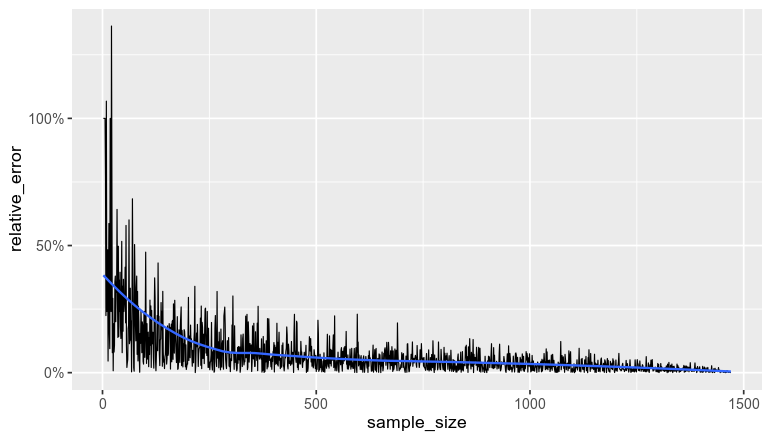

# ***Creating a Sampling Distribution***

A distribution of multiple values of any point estimate is known as "***sampling distribution***".

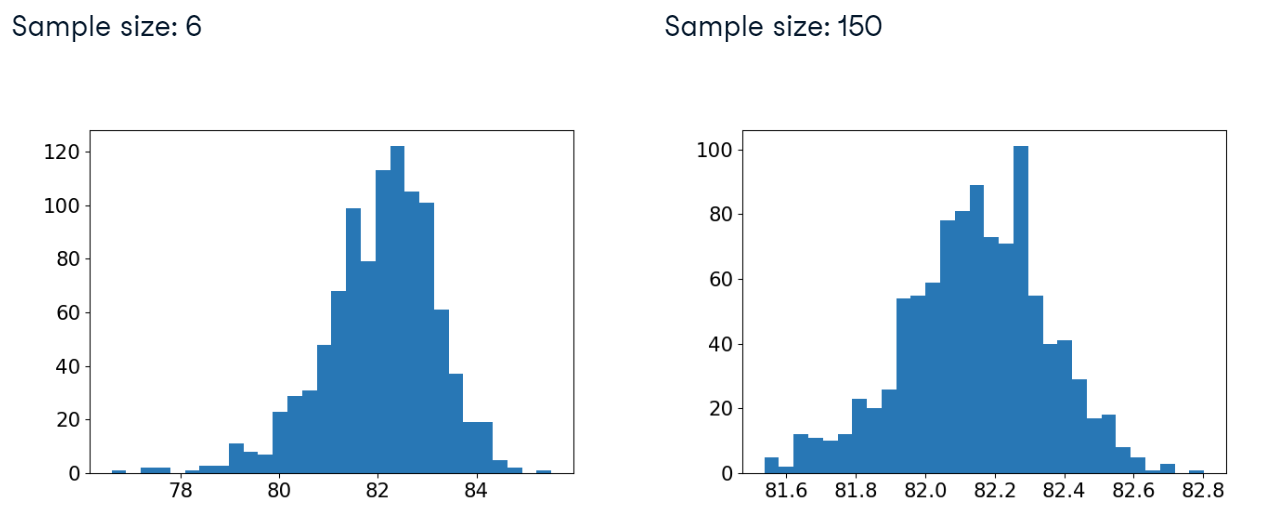

More observations lead to narrower range of distribution.

## ***Mean of means***



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

coffee_ratings = pd.read_feather('coffee_ratings_full.feather')

mean_cup_points_1000 = [coffee_ratings.sample(n=30)['total_cup_points'].mean() for i in range(1000)]

fig, ax = plt.subplots()
ax.hist(mean_cup_points_1000, bins=60, edgecolor='white')
plt.show()

#### ***Exercise: Replicating samples***

When you calculate a point estimate such as a sample mean, the value you calculate depends on the rows that were included in the sample. That means that there is some randomness in the answer. In order to quantify the variation caused by this randomness, you can create many samples and calculate the sample mean (or another statistic) for each sample.

* Replicate the provided code so that it runs `500` times. Assign the resulting list of sample means to `mean_attritions`.
* Draw a histogram of the `mean_attritions` list with `16` bins.

In [ ]:
import pandas as pd

attrition_pop = pd.read_feather('attrition.feather')

# Create an empty list
mean_attritions = []
# Loop 500 times to create 500 sample means
for i in range(500):
	mean_attritions.append(attrition_pop.sample(n=60)['Attrition'].mean())

# Create a histogram of the 500 sample means
plt.hist(mean_attritions, bins=16, edgecolor='white')
plt.show()

By generating the sample statistic many times with different samples, you can quantify the amount of variation in those statistics.  As sample size increases, on average each sample mean has a lower relative error compared to the population mean, thus reducing the range of the distribution.

#### **Exercise: Replication parameters**
The dashboard shows a histogram of sample mean proportions of employee attrition. There are two parameters:
* the size of each simple random sample, and
* the number of replicates.

It's important to understand how each of these parameters affects the result.

## Sample=25, Replicates=25
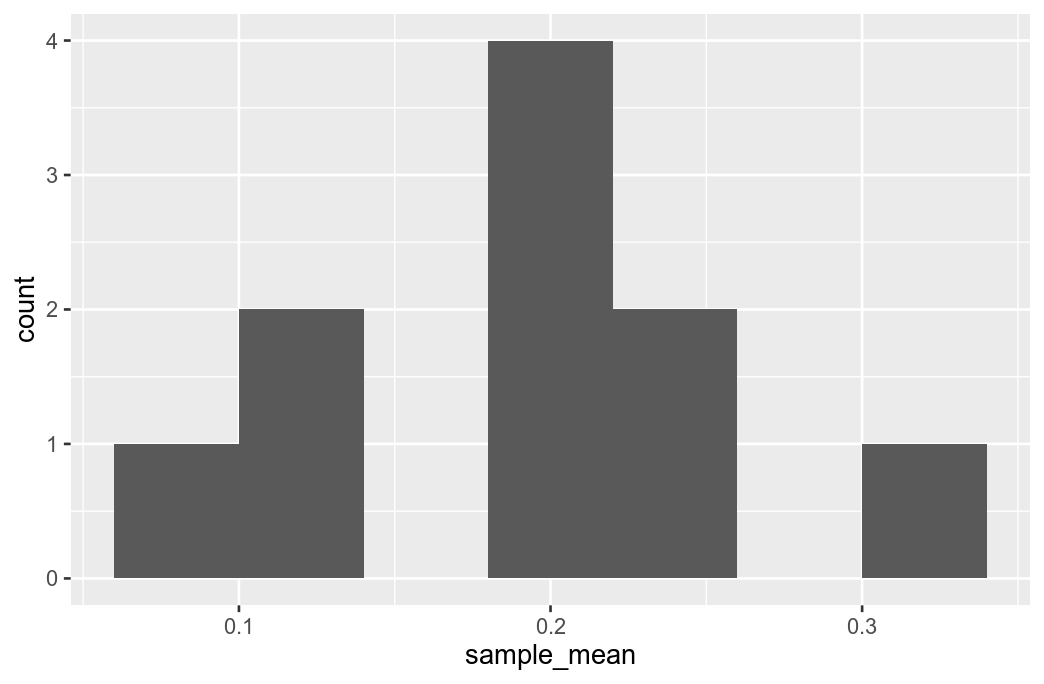

## Sample=25, Replicates=10,000
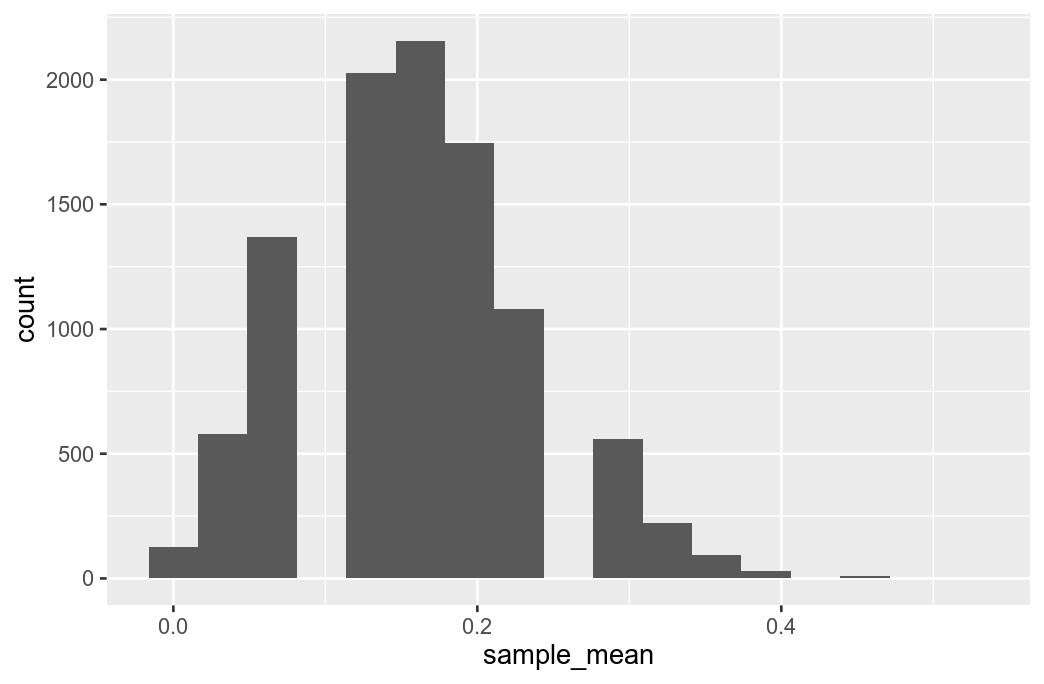

## Sample=800, Replicates=25
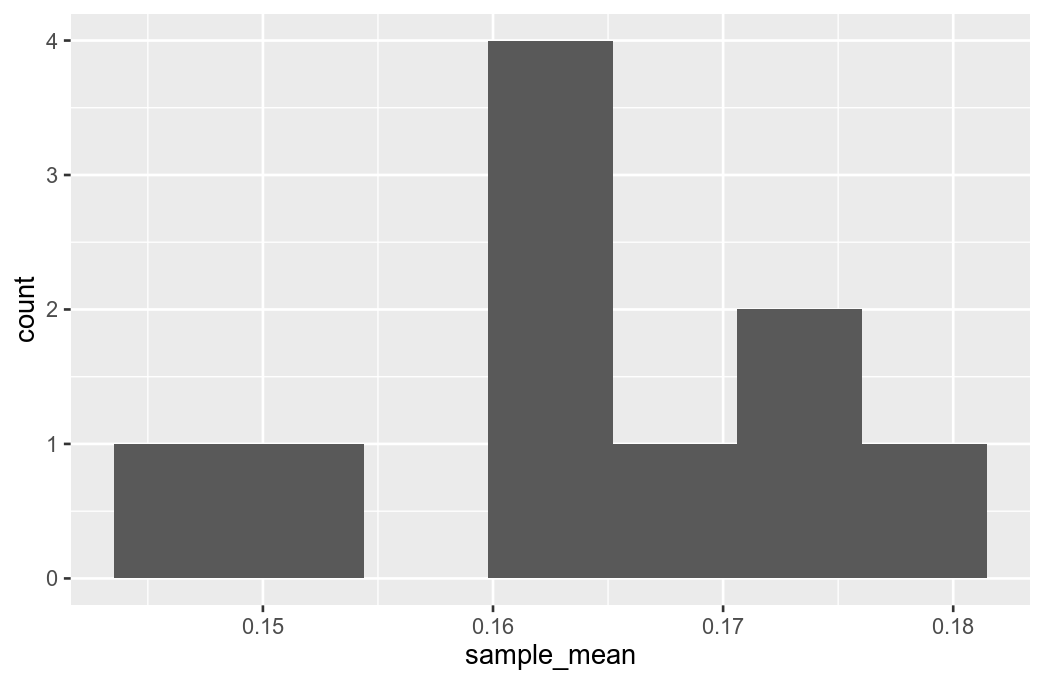

## Sample=800, Replicates=10,000
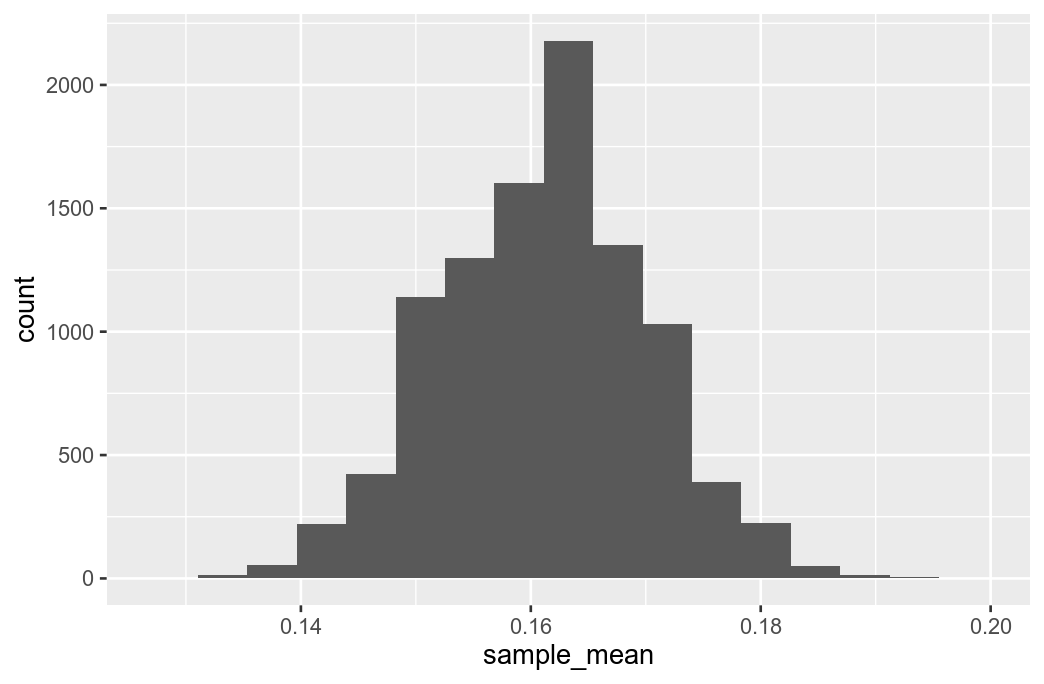

# ***As the sample size increases, the range of calculated sample means tends to decrease.***   

As sample size increases, on average each sample mean has a lower relative error compared to the population mean, thus reducing the range of the distribution.



# **Approximate Sampling Distributions**

- Consider throwing 4 dices

In [ ]:
from itertools import product
import pandas as pd, matplotlib.pyplot as plt, numpy as np

die1, die2, die3, die4 = [1, 2, 3, 4, 5, 6], [1, 2, 3, 4, 5, 6], [1, 2, 3, 4, 5, 6], [1, 2, 3, 4, 5, 6]
dice = pd.DataFrame(data=product(die1, die2, die3, die4), columns=['die1', 'die2', 'die3', 'die4'])
dice

## **Mean of each row**


In [ ]:
dice['mean_roll'] = dice.sum(axis=1) / 4
dice

## **Exact sampling distribution**

First, we convert `mean_roll` to categorical variable by setting its type to `category`.

In [ ]:
dice['mean_roll'] = dice['mean_roll'].astype('category')

We are interested in the counts of each value.

In [ ]:
dice['mean_roll'].value_counts(sort=False).plot(kind='bar')
plt.show()

## **Impossible to create exact sampling distributions due to large possible outcomes**

* One dice has 6 results
* Four dice have $6^4 = 1296$
* One hundred dices have $6^{100}$

## **Simulating the mean of 4 dice rolls**

In [ ]:
# Sample outcome of randomly throwing 4 dices
np.random.choice(list(range(1, 7)), size=4, replace=True)

In [ ]:
# replace=True is sampling with replacement
sample_means_1000 = [np.random.choice(list(range(1, 7)), size=4, replace=True).mean() for i in range(1000)]
plt.hist(sample_means_1000, bins=20, edgecolor='white'); plt.show()



#### ***Exercise: Exact sampling distribution***

To quantify how the point estimate (sample statistic) you are interested in varies, you need to know all the possible values it can take and how often. That is, you need to know its distribution.

The distribution of a sample statistic is called the ***sampling distribution***. When we can calculate this exactly, rather than using an approximation, it is known as the <u>*exact sampling distribution*</u>.

Let's take another look at the sampling distribution of dice rolls. This time, we'll look at five eight-sided dice. (These have the numbers one to eight.)

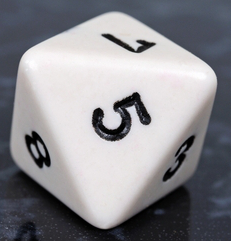

`pandas`, `numpy`, and `matplotlib.pyplot` are loaded with their usual aliases. The `expand_grid()` function is also available, which expects a dictionary of key-value pairs as its argument. The definition of the `expand_grid()` function is provided in the [pandas documentation](https://pandas.pydata.org/pandas-docs/version/0.17.1/cookbook.html#creating-example-data).

* Expand a grid representing 5 8-sided dice. That is, create a DataFrame with five columns from a dictionary, named die1 to die5. The rows should contain all possibilities for throwing five dice, each numbered 1 to 8.

* Add a column, `mean_roll`, to dice, that contains the mean of the five rolls as a `categorical`.



In [ ]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt

def expand_grid(data_dict):
    rows = itertools.product(*data_dict.values())
    return pd.DataFrame.from_records(rows, columns=data_dict.keys())

# Expand a grid representing 5 8-sided dice
dice = expand_grid(
  {'die1': [1, 2, 3, 4, 5, 6, 7, 8],
   'die2': [1, 2, 3, 4, 5, 6, 7, 8],
   'die3': [1, 2, 3, 4, 5, 6, 7, 8],
   'die4': [1, 2, 3, 4, 5, 6, 7, 8],
   'die5': [1, 2, 3, 4, 5, 6, 7, 8]
  })

# Add a column of mean rolls and convert to a categorical
dice['mean_roll'] = (dice['die1'] + dice['die2'] +
                     dice['die3'] + dice['die4'] +
                     dice['die5']) / 5
dice['mean_roll'] = dice['mean_roll'].astype('category')

# Draw a bar plot of mean_roll
dice['mean_roll'].value_counts(sort=False).plot(kind="bar")
plt.show()

The exact sampling distribution shows all possible variations of the point estimate that you are interested in.

#### ***Exercise: Approximate sampling distribution***

Calculating the exact sampling distribution is only possible in very simple situations. With just five eight-sided dice, the number of possible rolls is 8**5, which is over thirty thousand. When the dataset is more complicated, for example, where a variable has hundreds or thousands of categories, the number of possible outcomes becomes too difficult to compute exactly.

In this situation, you can calculate an approximate sampling distribution by simulating the exact sampling distribution. That is, you can repeat a procedure over and over again to simulate both the sampling process and the sample statistic calculation process.

* Sample one to eight, five times, with replacement. Assign to `five_rolls`.
* Calculate the mean of `five_rolls`.

* Replicate the sampling code 1000 times, assigning each result to the list `sample_means_1000`.

* Plot `sample_means_1000` as a histogram with 20 `bins`.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sample one to eight, five times, with replacement
five_rolls = np.random.choice(list(range(1, 9)), size=5, replace=True)

# Print the mean of five_rolls
print(five_rolls.mean())


# Replicate the sampling code 1000 times
sample_means_1000 = []
for i in range(1000):
    sample_means_1000.append(np.random.choice(list(range(1, 9)), size=5, replace=True).mean())

# Print the first 10 entries of the result
print(sample_means_1000[0:10])

# Draw a histogram of sample_means_1000 with 20 bins
plt.hist(sample_means_1000, bins=20, edgecolor='white')
plt.show()

Once your dataset gets sufficiently big, <ins>***exact sampling distributions cannot be calculated***</ins>, so an approximate sampling distribution must be used. Notice that the histogram is close to but <ins>***not exactly the same***</ins> as the shape of the bar graph from the previous exercise.

The <ins>***exact sampling distribution***</ins> can only be calculated if you know what the population is and if the problems are small and simple enough to compute. Otherwise, the <ins>***approximate sampling distribution***</ins> must be used.

# **Standard Errors and the Central Limit Theorem**

## **Sampling distribution of the mean cup points**

In [ ]:
df = pd.read_feather('/content/coffee_ratings_full.feather')
df['total_cup_points'].mean()

In [ ]:
size5 = [df['total_cup_points'].sample(n=5).mean() for i in range(5000)]
size20 = [df['total_cup_points'].sample(n=20).mean() for i in range(5000)]
size80 = [df['total_cup_points'].sample(n=80).mean() for i in range(5000)]
size320 = [df['total_cup_points'].sample(n=320).mean() for i in range(5000)]

fig, ax = plt.subplots(2,2)
ax[0,0].hist(size5, bins=20, edgecolor='white'); ax[0, 0].set_title('Sample size: 5')
ax[0,1].hist(size20, bins=20, edgecolor='white'); ax[0, 1].set_title('Sample size: 20')
ax[1,0].hist(size80, bins=20, edgecolor='white'); ax[1, 0].set_title('Sample size: 80')
ax[1,1].hist(size320, bins=20, edgecolor='white'); ax[1, 1].set_title('Sample size: 320')
plt.tight_layout()
plt.show()



# ***Central limit theorem***

The width of the distribution shrinks as the <u>***sample size***</u> increases.  

* As the sample size increases, the curve gets closer to the normal distribution.
>>  * The ***means*** of independent samples have normal distributions!

  

In [ ]:
for i, j in zip([5, 20, 80, 320], [size5, size20, size80, size320]):
    print(f'The mean of the sample of size {i} is {np.mean(j)}.', "\n")

The mean becomes closer to the population mean as sample size gets bigger.

## ***Standard deviations of the Sample Mean***

> - Be careful here.  We are discussing the standard deviations of the sample means, ***<U>NOT</U> THE STANDARD DEVIATIONS OF THE SAMPLES***.

> (It was I who made a stupid mistake because I was rusty in statistics.)

Standard deviations (and all other statistics) have normal distribution as sample size gets bigger too!

Below, notice that the standard deviations of the sample means calculated by `np.std(mean_data, ddof=1)` approximately equals population standard deivation divided by $n$

$$s_{\bar x} = \frac{\sigma}{\sqrt{n}}$$

This $s_{\bar x}$ is also known as standard error of the sample mean

In [ ]:
np.random.seed(42)
std5 = [df['total_cup_points'].sample(n=5).mean() for i in range(5000)]
std20 = [df['total_cup_points'].sample(n=20).mean() for i in range(5000)]
std80 = [df['total_cup_points'].sample(n=80).mean() for i in range(5000)]
std320 = [df['total_cup_points'].sample(n=320).mean() for i in range(5000)]

for i, j in zip([5, 20, 80, 320], [std5, std20, std80, std320]):
    print(f'The SD of the sampling distribution of the sample mean for n = {i} is {np.std(j, ddof=1)}.')

pop_std = df["total_cup_points"].std(ddof=0)

for i in [5, 20, 80, 320]:
    print(f'{pop_std:.4f} / sqrt({i}) = {pop_std / np.sqrt(i)}.')

We get an APPROXIMATE of standard deviations of sample means by dividing by $\sqrt{n}$ where $n$ is sample size.

## **Standard Errors**

โดยทั่วไป ไม่มีสิ่งที่เรียกว่า “standard error of a sample” เฉย ๆ แบบนั้น

ต้องระบุว่า standard error ของอะไร เช่น

- SE of the mean → \($\sigma/\sqrt n\$)
- SE of a proportion
- SE of a regression coefficient
- SE of a sample standard deviation เป็นต้น



#### ***Exercise: Population & sampling distribution means***

One of the useful features of sampling distributions is that you can quantify them. Specifically, you can calculate summary statistics on them. Here, you'll look at the relationship between the mean of the sampling distribution and the population parameter's mean.

Three sampling distributions are provided. For each, the employee attrition dataset was sampled using simple random sampling, then the mean attrition was calculated. This was done 1,000 times to get a sampling distribution of mean attritions. One sampling distribution used a sample size of 5 for each replicate, one used 50, and one used 500.

`attrition_pop`, `sampling_distribution_5`, `sampling_distribution_50`, and `sampling_distribution_500` are available; numpy as `np` is loaded.

* Calculate the mean of `sampling_distribution_5`, `sampling_distribution_50`, and `sampling_distribution_500` (a mean of sample means).

In [ ]:
import numpy as np
import pandas as pd

attrition_pop = pd.read_feather('attrition.feather')

sampling_distribution_5, sampling_distribution_50, sampling_distribution_500 = [], [], []
s = [sampling_distribution_5, sampling_distribution_50,  sampling_distribution_500]
for i, j in zip(s, [5, 50, 500]):
    for k in range(1000):
        i.append(attrition_pop['Attrition'].sample(n=j).mean())

# Calculate the mean of the mean attritions for each sampling distribution
mean_of_means_5 = np.mean(sampling_distribution_5)
mean_of_means_50 = np.mean(sampling_distribution_50)
mean_of_means_500 = np.mean(sampling_distribution_500)

# Print the results
print(attrition_pop['Attrition'].mean())
print(mean_of_means_5)
print(mean_of_means_50)
print(mean_of_means_500)

Even for small sample sizes, the mean of the sampling distribution is a good approximation of the population mean.

#### ***Exercise: Population & sampling distribution variation***

You just calculated the mean of the sampling distribution and saw how it is an estimate of the corresponding population parameter. Similarly, as a result of the central limit theorem, the standard deviation of the sampling distribution has an interesting relationship with the population parameter's standard deviation and the sample size.

`attrition_pop`, `sampling_distribution_5`, `sampling_distribution_50`, and `sampling_distribution_500` are available.

* Calculate the standard deviation of `sampling_distribution_5`, `sampling_distribution_50`, and `sampling_distribution_500` (a standard deviation of sample means).

In [ ]:
# Calculate the std. dev. of the mean attritions for each sampling distribution
sd_of_means_5 = np.std(sampling_distribution_5, ddof=1)
sd_of_means_50 = np.std(sampling_distribution_50, ddof=1)
sd_of_means_500 = np.std(sampling_distribution_500, ddof=1)

# Print the results
print(sd_of_means_5, attrition_pop['Attrition'].std(ddof=0)/np.sqrt(5))
print(sd_of_means_50, attrition_pop['Attrition'].std(ddof=0)/np.sqrt(50))
print(sd_of_means_500, attrition_pop['Attrition'].std(ddof=0)/np.sqrt(500))

The standard deviation of the sampling distribution is approximately equal to the <ins>***population standard deviation divided by the square root of the sample size***</ins>.

The amount of variation in the sampling distribution is related to the amount of variation in the population and the sample size. This is another consequence of the Central Limit Theorem.

>> ### ***Note for myself***
>> I have totally forgotten most knowledge regarding standard deviations, standard deviations of sample statistics, and standard errors.  Here is note for my own.  The confusion came due to the fact that we treat the whole dataset as population and then we draw samples out of this dataset as many times as we want to collect some statistics like means of each samples.  In reality you have only one sample from population.

- ใน python ตัว standard error ของ sample mean มันหาได้จาก `np.std(samples_of_means, ddof=1)` ใช่ไหม


In [ ]:
import numpy as np

# Simulation: Population with mean 50, std 10
pop = np.random.normal(50, 10, 100000)
pop_std = np.std(pop)

# Take 1000 samples of size n=30
n = 30
sample_means = [np.mean(np.random.choice(pop, n)) for _ in range(1000)]

# Theoretical SEM = pop_std / sqrt(n)  (SEM คือ Standard Error of Mean)
theoretical_sem = pop_std / np.sqrt(n)

# Empirical SEM using std of sample_means
empirical_sem = np.std(sample_means, ddof=1)

print(f"Theoretical SEM: {theoretical_sem}")
print(f"Empirical SEM (std of sample_means): {empirical_sem}")

>> กรณีที่ 1: `samples_of_means` คืออาร์เรย์ที่เก็บ "ค่าเฉลี่ยของหลายๆ กลุ่มตัวอย่าง"
(เช่น ได้จากการจำลอง Monte Carlo Simulation หรือการทำ Bootstrapping ไว้หลายๆ รอบ)

>> คำนวณค่า SD ของชุดค่าเฉลี่ยเหล่านั้นที่มีขนาดตัวอย่าง = $k$:

$$\text{SE} \approx \sqrt{\frac{1}{k-1} \sum_{i=1}^{k} (\bar{x}_i - \bar{X})^2}= \texttt{np.std(samples_of_means, ddof=1)}$$

>> กรณีที่ 2: มีข้อมูลดิบเพียง "กลุ่มตัวอย่างเดียว" (Single Sample)หากตัวแปรเป็นข้อมูลดิบ $\mathbb{x} = [x_1, x_2, ..., x_n]$ การหา Standard Error จากกลุ่มตัวอย่างเดียวจะต้องใช้สูตร:$$SE_{\bar{x}} = \frac{s}{\sqrt{n}} = \frac{\texttt{np.std}(\mathbb{x}, \texttt{ddof}=1)}{\sqrt{n}}$$

In [ ]:
# วิธีที่ 1: ใช้ NumPy คำนวณตรงๆ
se = np.std(sample, ddof=1) / np.sqrt(len(sample))

# วิธีที่ 2: ใช้ SciPy (แนะนำเพราะสั้นและตรงเป้าหมาย)
from scipy import stats
se = stats.sem(sample)

>> ***ข้อสรุป (Verdict)***

>> หากตัวแปร `samples_of_means` เป็นชุดข้อมูลที่รวบรวม "ค่าเฉลี่ยจากการสุ่มซ้ำหลายๆ รอบ" ไว้แล้ว การใช้คำสั่ง `np.std(samples_of_means, ddof=1)` ถือว่า ถูกต้อง ตามนิยามของการหา Empirical Standard Error

>> แต่ถ้าหากมี "ข้อมูลดิบชุดเดียว" การใช้ `np.std(sample, ddof=1)` โดดๆ จะได้เพียง Sample SD เท่านั้น ยังไม่ใช่ Standard Error (ต้องหารด้วย `np.sqrt(n)` เพิ่มเติม)

# **Introduction to Bootstrapping**

## ***Sampling with Replacement (Resampling)***

### ***Coffee data preparation***

In [ ]:
import pandas as pd

coffee_ratings = pd.read_feather('coffee_ratings_full.feather')

# Focus only on 3 columns
coffee_focus = coffee_ratings[["variety", "country_of_origin", "flavor"]]
coffee_focus = coffee_focus.reset_index() # reset index to see the result of sampling with replacement
coffee_focus

## ***Sample with replacement***

* Setting `frac=1` produces a <u>sample of the same size as the original dataset</u>
* Notice that `index` can be repeated

In [ ]:
coffee_resamp = coffee_focus.sample(frac=1, replace=True)
coffee_resamp["index"].value_counts()

Sampling with replacement will most likely result in some observations being drawn more than one time.

# ***Bootstrapping***

The opposite of sampling from a population

**<u>Sampling**</u>
  * Dataset is a population and move to smaller samples.

**<u>Bootstrapping</u>**

  * Dataset is a sample and build up a theoretical population from the sample.

## ***Principles of bootstrapping***

Bootstrapping is, in some sense, the opposite of sampling from a population. Sampling treats your dataset as the population, and you generate a random subset. Bootstrapping treats your dataset as a sample and uses it to build up a theoretical population.

## ***Bootstrap Steps***

The bootstrapping workflow is to generate a resample of the same size as the population, calculate a summary statistic, then repeat this to get a distribution of summary statistics.

1. Make a resample (with replacement) of the same size as the original sample
2. Calculate the statistic of interest for this bootstrap sample
3. Repeat steps 1 and 2 many times, e.g., 1,000 times

The resulting statistics are bootstrap statistics, and they form a **"bootstrap distribution"**.

# This means that in this chapter we treat our dataset as SAMPLE

### ***Example: Bootstrapping coffee mean flavor***

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#                    1. Resample with replacement -----2. Find statistics------3. Repeat 1,000 times
mean_flavors_1000 = [coffee_focus.sample(frac=1, replace=True)['flavor'].mean() for i in range(1000)]
plt.hist(mean_flavors_1000, edgecolor='white')
plt.show()

#### **Exercise: Principles of bootstrapping**

*Bootstrapping* is, in some sense, the opposite of sampling from a population.

* **Sampling** treats your dataset as the population, and you generate a random subset.
* **Bootstrapping** treats your dataset as a sample and uses it to build up a theoretical population.
  
    1. Bootstrap resamples should be the same size as the original sample.
    2. A bootstrap distribution consists of many replicates of the statistic of interest.
    3. Each row in the dataset should have an equally likely chance of being drawn in a resample.

    

#### **Exercise: With or without replacement**

So far, you've seen sampling with and without replacement. It's important to know when to use each method.

<u>*Sampling with replacement examples*</u>

* A small hedge fund lacks the resources to track every stock, but feels confident that the 100 stocks they have tracked represent the market.

* While studying variability in tigers' weights, you collected data on 10 tigers.  You suspect that there are around 50 in your region.

<u>*Without replacement*</u>

* A social media company released all their members' posts from last year.  You need to report on this data to your manager by the end of the week.

* A regional census was conducted to understand the mean income of people living there. Analyzing the full dataset will take too much time.

 The key to deciding whether to sample without or with replacement is whether or not your dataset is best thought of as being the whole population or not.



#### ***Exercise: Generating a bootstrap distribution***

The process for generating a bootstrap distribution is similar to the process for generating a sampling distribution; only the first step is different.

To make a
* sampling distribution,
* you start with the population and sample ***without replacement***.

To make a
* bootstrap distribution,
* you start with a sample and sample that ***with replacement***.

After that, the steps are the same: calculate the summary statistic that you are interested in on that sample/resample, then replicate the process many times. In each case, you can visualize the distribution with a histogram.

Here, `spotify_sample` is a subset of the `spotify_population` dataset. To make it easier to see how resampling works, a row index column called `'index'` has been added, and only the artist name, song name, and danceability columns have been included.

* Generate a single bootstrap resample from `spotify_sample`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spotify_sample = pd.read_feather('spotify_2000_2020.feather').reset_index()[['artists', 'name', 'danceability']]

# Replicate this 1000 times
mean_danceability_1000 = []
for i in range(1000):
	mean_danceability_1000.append(
        np.mean(spotify_sample.sample(frac=1, replace=True)['danceability']))

mean_danceability_samp = []
for i in range(1000):
	mean_danceability_samp.append(
        np.mean(spotify_sample.sample(frac=0.1, replace=False)['danceability']))

# Draw a histogram of the resample means from bootstrap distribution
plt.hist(mean_danceability_1000, bins=50, edgecolor='white')
plt.axvline(x=np.mean(mean_danceability_1000), color='red', linestyle='--')
plt.show()

# Draw a histogram of the sampling distribution
plt.hist(mean_danceability_samp, bins=50, edgecolor='white')
plt.axvline(x=np.mean(mean_danceability_samp), color='red', linestyle='--')
plt.show()

From the smaller sample of Spotify songs, we can estimate the mean danceability statistic in the population. Since we have a distribution of statistics, we can even quantify how accurate our estimate is.
n

# **Comparing sampling and bootstrap distribution**

## **Bootstrap Distribution from 500 samples from coffee dataset**

- Here, the whole dataset is population
- We draw 500 samples from it
- And use this 500 samples to simulate the population using bootstrapping

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

coffee_ratings = pd.read_feather('coffee_ratings_full.feather')

coffee_sample = coffee_ratings[["variety", "country_of_origin", "flavor"]].reset_index().sample(n=500)

mean_flavors_5000 = []
for i in range(5000):
    mean_flavors_5000.append(np.mean(coffee_sample.sample(frac=1, replace=True)['flavor']))

bootstrap_distn = mean_flavors_5000
plt.hist(bootstrap_distn, bins=50, edgecolor='white')
plt.title('Bootstrap distribution of mean flavor')
plt.show()

sampling_distn = [np.mean(coffee_ratings['flavor'].sample(n=500)) for i in range(5000)]

plt.hist(sampling_distn, bins=30, edgecolor='white')
plt.title('Sample distribution of mean flavor')
plt.show()

The bootstrap distribution looks like a normal distribution.

>>> ***Data dispersion in bootstrap is less than that in sampling.  This implies a smaller standard deviation***

# ***Sample, bootstrap distribution, population means***

* Sample mean

In [ ]:
coffee_sample['flavor'].mean()

* "*Estimated*" population mean:
  * The bootstrap sample mean is usuallly almost identical to the original sample mean.

In [ ]:
np.mean(bootstrap_distn)

* ***True*** population mean:
  * The true popluation mean is actually a little different.

In [ ]:
coffee_ratings['flavor'].mean()

This is problematic if your original sample is not a representative of the whole population.  If this happens, simulating the whole population using bootstrapping is unlikely to work
## ***Sample standard deviation***

- NumPy np.std() → ddof=0 เป็นค่า default
- pandas Series.std() → ddof=1 เป็นค่า default

In [ ]:
# ddof=1 is the default value for ddof in .std() method
coffee_sample['flavor'].std(ddof=1)

## ***Population standard deviation***

In [ ]:
coffee_ratings['flavor'].std(ddof=0)

## ***Bootstrap standard deviation***

In [ ]:
# Standard error of the MEANS
np.std(bootstrap_distn, ddof=1)

Standard error of the bootstrap means  $\approx \dfrac{\text{Sample Standard Deviation}}{\sqrt{\text{# Sample size}}}$

In [ ]:
# We drew 500 samples
coffee_sample['flavor'].std()/np.sqrt(500)

In [ ]:
np.std(bootstrap_distn, ddof=1) * np.sqrt(500)

Estimated standard error → standard deviation of the bootstrap distribution for a sample statistic ในที่นี้คือ sd ของ mean ถึงแม้ว่า bootstrap จะประมาณค่าทางสถิติได้ไม่ดีนัก เพราะขึ้นกับว่ากลุ่มตัวอย่างที่สุ่มมาสอดคล้องกับประชากรหรือไม่ แต่เราสามารถใช้

Population std. dev ≈ Std. Error $\times \sqrt{\text{# Sample size}}$

เพื่อประมาณ ส่วนเบี่ยงเบนมาตรฐานของประชากรได้

#### **Exercise: Bootstrap statistics and population statistics**

Bootstrap distribution statistics can be used to estimate population parameters. But can you always rely on them to give an accurate estimate of an unknown population parameter?

Should the mean and the standard deviation of the bootstrap distribution both be used to estimate the corresponding values of the population?

If the sample is <u>NOT</u> closely representative of the population, then the mean of the bootstrap distribution will not be representative of the population mean. This is less of a problem for standard errors.



#### ***Exercise: Sampling distribution vs. bootstrap distribution***

The sampling distribution and bootstrap distribution are closely linked. In situations where you can repeatedly sample from a population (these occasions are rare), it's helpful to generate both the sampling distribution and the bootstrap distribution, one after the other, to see how they are related.

Here, the statistic you are interested in is the mean popularity score of the songs.

`spotify_population` (the whole dataset) and `spotify_sample` (500 randomly sampled rows from `spotify_population`) are available.


1. Generate a sampling distribution of 2,000 replicates.
  * Sample 500 rows of the <ins>***population***</ins> without replacement and calculate the mean popularity.

2. Generate a bootstrap distribution of 2,000 replicates.
  * Sample 500 rows of the <ins>***sample***</ins> with replacement and calculate the mean popularity.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spotify_population = pd.read_feather('spotify_2000_2020.feather').reset_index()
spotify_sample = spotify_population.sample(n=500)

mean_popularity_2000_samp = []

# Generate a sampling distribution of 2000 replicates
for i in range(2000):
    mean_popularity_2000_samp.append(
    	# Sample 500 rows and calculate the mean popularity
    	np.mean(spotify_population.sample(n=500)['popularity']))

mean_popularity_2000_boot = []

# Generate a bootstrap distribution of 2000 replicates
for i in range(2000):
    mean_popularity_2000_boot.append(
    	# Resample 500 rows and calculate the mean popularity
    	np.mean(spotify_sample.sample(n=500, replace=True)['popularity']))

plt.hist(mean_popularity_2000_samp, bins=50, edgecolor='white')
plt.title('Sampling mean distribution')
plt.show()

plt.hist(mean_popularity_2000_boot, bins=50, edgecolor='white')
plt.title('Bootstrap mean distribution')
plt.show()

The sampling distribution and bootstrap distribution are closely related, and so is the code to generate them.

#### ***Exercise: Compare sampling and bootstrap means***

To make calculation easier, distributions similar to those calculated from the previous exercise have been included, this time using a sample size of 5,000.

* Calculate the mean popularity in 4 ways:

  * Population: from `spotify_population`, take the mean of popularity.
  * Sample: from `spotify_sample`, take the mean of popularity.
  * Sampling distribution: from `sampling_distribution`, take its mean.
  * Bootstrap distribution: from `bootstrap_distribution`, take its mean.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

spotify_population = pd.read_feather('spotify_2000_2020.feather').reset_index()
spotify_sample = spotify_population.sample(n=5000)

sampling_distribution = []

# Generate a sampling distribution of 5000 replicates
for i in range(5000):
    sampling_distribution.append(
    	# Sample 500 rows and calculate the mean popularity
    	np.mean(spotify_population.sample(n=5000)['popularity']))

bootstrap_distribution = []

# Generate a bootstrap distribution of 5000 replicates
for i in range(5000):
    bootstrap_distribution.append(
    	# Resample 500 rows and calculate the mean popularity
    	np.mean(spotify_sample.sample(n=5000, replace=True)['popularity']))
#############################################################################

# Calculate the population mean popularity
pop_mean = spotify_population['popularity'].mean()

# Calculate the original sample mean popularity
samp_mean = spotify_sample['popularity'].mean()

# Calculate the sampling dist'n estimate of mean popularity
samp_distn_mean = np.mean(sampling_distribution)

# Calculate the bootstrap dist'n estimate of mean popularity
boot_distn_mean = np.mean(bootstrap_distribution)

# Print the means
print([pop_mean, samp_mean, samp_distn_mean, boot_distn_mean])

The sampling distribution mean, 54.83864856,  is the best estimate of the true population mean, 54.837142308430955; the bootstrap distribution mean, 54.73390896000001, is closest to the original sample mean, 54.7392.

The sampling distribution mean can be used to estimate the population mean, but that is not the case with the bootstrap distribution.

#### ***Exercise: Compare sampling and bootstrap standard deviations***

In the same way that you looked at how the sampling distribution and bootstrap distribution could be used to estimate the population mean, you'll now take a look at how they can be used to estimate variation, or more specifically, the standard deviation, in the population.

Recall that the sample size is 5000.

* Calculate the standard deviation of popularity in 4 ways.

  * Population: from `spotify_population`, take the standard deviation of `popularity`.
  * Original sample: from `spotify_sample`, take the standard deviation of `popularity`.
  * Sampling distribution: from `sampling_distribution`, take its standard deviation and multiply by the square root of the sample size (`5000`).
  * Bootstrap distribution: from `bootstrap_distribution`, take its standard deviation and multiply by the square root of the sample size.

In [ ]:
# Calculate the population std dev popularity
pop_sd = spotify_population['popularity'].std(ddof=0)

# Calculate the original sample std dev popularity
samp_sd = spotify_sample['popularity'].std(ddof=1)

# Calculate the sampling dist'n estimate of std dev popularity
samp_distn_sd = np.std(sampling_distribution, ddof=1)*np.sqrt(5000)

# Calculate the bootstrap dist'n estimate of std dev popularity
boot_distn_sd = np.std(bootstrap_distribution, ddof=1)*np.sqrt(5000)

# Print the standard deviations
print([pop_sd, samp_sd, samp_distn_sd, boot_distn_sd])

This is an important property of the bootstrap distribution. When you don't have all the values from the population or the ability to sample multiple times, you can use bootstrapping to get a good estimate of the population standard deviation.

# ***Confidence Interval***

## ***Bootstrap distribution of mean flavor***

### ***Mean of resamples***

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Treat as population
coffee_pop = pd.read_feather('coffee_ratings_full.feather')

# Treat as 500 samples
coffee_samp = coffee_pop.sample(n=500)

# Bootstrapping from 500 samples for 5,000 times
coffee_boot_distn = [np.mean(coffee_samp.sample(frac=1, replace=True)['flavor']) for i in range(5000)]

plt.hist(coffee_boot_distn, bins=15, edgecolor='white')
plt.axvline(x=np.mean(coffee_boot_distn), linestyle='--', color='red')
plt.axvline(x=np.mean(coffee_boot_distn) - np.std(coffee_boot_distn, ddof=1), linestyle='--', color='yellow')
plt.axvline(x=np.mean(coffee_boot_distn) + np.std(coffee_boot_distn, ddof=1), linestyle='--', color='purple')
plt.show()

# ***Quantile method for confidence intervals***

## ***95% Confidence Interval***

In [ ]:
plt.hist(coffee_boot_distn, bins=15, edgecolor='white')
plt.axvline(x=np.quantile(coffee_boot_distn, 0.025), linestyle='--', color='yellow')
plt.axvline(x=np.quantile(coffee_boot_distn, 0.975), linestyle='--', color='purple')
plt.show()

# ***Inverse cumulative distribution function***

In [ ]:
from scipy.stats import norm

# c.d.f. has the values between 0 and 1 and this is the domain of the inverse c.d.f.
plt.plot(np.linspace(0.001, 0.999, 1000), norm.ppf(np.linspace(0.001, 0.999, 1000), loc=0, scale=1))
plt.xlabel('Quantile'); plt.ylabel('Inverse CDF')
plt.show()

In [ ]:
from scipy.stats import norm
lower = norm.ppf(0.025, loc=np.mean(coffee_boot_distn), scale=np.std(coffee_boot_distn, ddof=1))
upper = norm.ppf(0.975, loc=np.mean(coffee_boot_distn), scale=np.std(coffee_boot_distn, ddof=1))
plt.hist(coffee_boot_distn, bins=15, edgecolor='white')
plt.axvline(x=lower, linestyle='--', color='yellow')
plt.axvline(x=upper, linestyle='--', color='purple')
plt.show()

### **Confidence interval interpretation**

When reporting results, it is common to provide a confidence interval alongside an estimate.

What information does that confidence interval provide?

*Confidence intervals account for uncertainty in our estimate of a population parameter by providing a range of possible values. We are confident that the true value lies somewhere in the interval specified by that range.*

#### ***Exercise: Calculating confidence intervals***

You have learned about two methods for calculating confidence intervals: the quantile method and the standard error method. The standard error method involves using the inverse cumulative distribution function (inverse CDF) of the normal distribution to calculate confidence intervals. In this exercise, you'll perform these two methods on the Spotify data.

`spotify_population`, `spotify_sample`, and `bootstrap_distribution` are available; `pandas` and `numpy` are loaded with their usual aliases, and `norm` has been loaded from `scipy.stats`.

1. Generate a 95% confidence interval using the quantile method on the bootstrap distribution, setting the `0.025` quantile as `lower_quant` and the `0.975` quantile as `upper_quant`.

2. Generate a 95% confidence interval using the standard error method from the bootstrap distribution.

* Calculate `point_estimate` as the mean of `bootstrap_distribution`, and `standard_error` as the standard deviation of `bootstrap_distribution`.
* Calculate `lower_se` as the `0.025` quantile of an inv. CDF from a normal distribution with mean `point_estimate` and standard deviation `standard_error`.
* Calculate `upper_se` as the `0.975` quantile of that same inv. CDF.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

spotify_population = pd.read_feather('spotify_2000_2020.feather')
spotify_sample = spotify_population.sample(n=500)
bootstrap_distribution = [np.mean(spotify_sample.sample(frac=1, replace=True)['popularity']) for i in range(5000)]

###############################################################################

# Generate a 95% confidence interval using the quantile method
lower_quant = np.quantile(bootstrap_distribution, 0.025)
upper_quant = np.quantile(bootstrap_distribution, 0.975)

# Print quantile method confidence interval
print((lower_quant, upper_quant))

# Find the mean and std dev of the bootstrap distribution
point_estimate = np.mean(bootstrap_distribution)
standard_error = np.std(bootstrap_distribution, ddof=1)

# Find the lower limit of the confidence interval
lower_se = norm.ppf(0.025, loc=point_estimate, scale=standard_error)

# Find the upper limit of the confidence interval
upper_se = norm.ppf(0.975, loc=point_estimate, scale=standard_error)

# Print standard error method confidence interval
print((lower_se, upper_se))

The standard error method for calculating the confidence interval ***assumes that the bootstrap distribution is normal***. This assumption should hold if the sample size and number of replicates are sufficiently large.